In [2]:
import pandas as pd
import keras
import tensorflow as tf 
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

I0000 00:00:1785819255.478115  194370 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785819255.478670  194370 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785819255.530077  194370 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785819256.854755  194370 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [94]:
performance_dict ={'MODEL':['Baseline cnn','Deep cnn','Cnn batch normalization','Cnn Dropout','Mobile net','Efficentnet','Resnet','Densenet'],
'ACCURACY': [0.48,0.65,0.50,0.46,0.61,0.67,0.66,0.58],
'LOSS':[1.34,1.91,1.70,1.35,0.96,0.74,1.21,1.07]

}

In [95]:
df = pd.DataFrame(performance_dict)

In [96]:
df.to_csv(r'../data/selected_col/performance.csv')

In [97]:
df_test = pd.read_csv(r'../data/selected_col/model_test.csv')

df_test = df_test.drop(columns=['Unnamed: 0'])

In [98]:
df_test

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,dx_encode
0,HAM_0000627,ISIC_0034019,nv,consensus,50.0,unknown,unknown,../data/all_image/ISIC_0034019.jpg,5
1,HAM_0001761,ISIC_0026732,nv,follow_up,30.0,male,abdomen,../data/all_image/ISIC_0026732.jpg,5
2,HAM_0002726,ISIC_0025473,nv,consensus,5.0,male,foot,../data/all_image/ISIC_0025473.jpg,5
3,HAM_0003424,ISIC_0033552,nv,histo,45.0,male,back,../data/all_image/ISIC_0033552.jpg,5
4,HAM_0004081,ISIC_0031957,mel,histo,70.0,female,lower extremity,../data/all_image/ISIC_0031957.jpg,4
...,...,...,...,...,...,...,...,...,...
1498,HAM_0006808,ISIC_0027438,nv,follow_up,65.0,male,lower extremity,../data/all_image/ISIC_0027438.jpg,5
1499,HAM_0002425,ISIC_0032682,nv,consensus,20.0,male,back,../data/all_image/ISIC_0032682.jpg,5
1500,HAM_0003747,ISIC_0026582,nv,follow_up,50.0,male,trunk,../data/all_image/ISIC_0026582.jpg,5
1501,HAM_0002807,ISIC_0025050,nv,follow_up,45.0,male,trunk,../data/all_image/ISIC_0025050.jpg,5


In [99]:
basic_cnn_model = keras.models.load_model(r'../models/bmodel_cnn_RMS.keras')

In [100]:
def preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (224,224))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [101]:
def preprocess_test(image_path, label):
    image, label = preprocess_image(image_path, label)
    return image, label

In [102]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        df_test["path"].values,
        df_test["dx_encode"].values
    )
)

test_dataset = (
    test_dataset
    .map(preprocess_test, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

In [103]:
img_size = (224,224)
batch_size = 32

In [104]:
def preprocess_image2(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, img_size)
    return image, label

In [105]:
def preprocess_test2(image_path, label):
    image, label = preprocess_image2(image_path, label)
    return image, label

In [106]:
test_dataset2 = tf.data.Dataset.from_tensor_slices(
    (
        df_test["path"].values,
        df_test["dx_encode"].values
    )
)

test_dataset2 = (
    test_dataset2
    .map(preprocess_test2, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

In [107]:
predict_prob = basic_cnn_model.predict(test_dataset)

47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 236ms/step


In [108]:
y_pred = np.argmax(predict_prob, axis=1)

In [109]:
'''true label'''

'true label'

In [110]:
y_true = []

for images, labels in test_dataset:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

In [111]:
'''performance dict'''

'performance dict'

In [112]:
evalution_dict ={}
evalution_dict['model'] =[]
evalution_dict['accuracy'] =[]
evalution_dict['precision'] = []
evalution_dict['recall'] = []
evalution_dict['roc-auc'] = []
evalution_dict['f1'] = []

In [113]:
'''baseline'''

'baseline'

In [114]:
accuracy = accuracy_score(y_true, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.6074517631403858


In [115]:
evalution_dict['model'].append('BASE LINE')
evalution_dict['accuracy'].append(accuracy)

In [116]:
precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Precision :", precision)

Precision : 0.6833055493420332


In [117]:
evalution_dict['precision'].append(precision)

In [118]:
recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Recall :", recall)

Recall : 0.6074517631403858


In [119]:
evalution_dict['recall'].append(recall)

In [120]:
f1 = f1_score(y_true,y_pred,average="weighted")

print("F1 Score :", f1)

F1 Score : 0.6152125021996068


In [121]:
evalution_dict['f1'].append(f1)

In [122]:


y_true_bin = label_binarize(
    y_true,
    classes=np.arange(7)
)

In [123]:
roc = roc_auc_score(y_true_bin,predict_prob,multi_class='ovr')
evalution_dict['roc-auc'].append(roc)
roc

0.8698757314746014

In [124]:
confusion_mat = confusion_matrix(y_true,y_pred)
confusion_mat

array([[  5,  11,  18,   2,   2,  11,   0],
       [  0,  39,  28,   3,   1,   6,   0],
       [  0,   8, 124,   0,   4,  29,   0],
       [  0,   9,   5,   2,   0,   1,   0],
       [  1,   8,  71,   1,  12,  71,   3],
       [  8,  16, 230,  11,  15, 722,   4],
       [  0,   6,   5,   1,   1,   0,   9]])

In [125]:
def calculation(y_true,y_pred,predict_prob):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true,y_pred,average="weighted")
    recall = recall_score(y_true,y_pred,average="weighted")
    f1 = f1_score(y_true,y_pred,average="weighted")
   

    y_true_bin = label_binarize(y_true,classes=np.arange(7))

    roc = roc_auc_score(y_true_bin,predict_prob,multi_class='ovr')

    return accuracy,precision,recall,f1,roc


In [126]:
def mat_app(model,accuracy,precision,recall,f1,roc):
    evalution_dict['model'].append(model)
    evalution_dict['accuracy'].append(accuracy)
    evalution_dict['precision'].append(precision)
    evalution_dict['recall'].append(recall)
    evalution_dict['f1'].append(f1)
    evalution_dict['roc-auc'].append(roc)

    return evalution_dict

In [127]:
'''deep'''

'deep'

In [128]:
deep_cnn_model = keras.models.load_model(r'../models/deep_model_adam.keras')

In [129]:
predict_prob = deep_cnn_model.predict(test_dataset)

47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 331ms/step


In [130]:
y_pred = np.argmax(predict_prob, axis=1)

In [131]:
accuracy,precision,recall,f1,roc = calculation(y_true,y_pred,predict_prob)

In [132]:
accuracy,precision,recall,f1,roc

(0.5029940119760479,
 0.6914449947547051,
 0.5029940119760479,
 0.5572814312505384,
 0.8278161193490473)

In [133]:
mat_app('DEEP CNN',accuracy,precision,recall,f1,roc)

{'model': ['BASE LINE', 'DEEP CNN'],
 'accuracy': [0.6074517631403858, 0.5029940119760479],
 'precision': [0.6833055493420332, 0.6914449947547051],
 'recall': [0.6074517631403858, 0.5029940119760479],
 'roc-auc': [0.8698757314746014, 0.8278161193490473],
 'f1': [0.6152125021996068, 0.5572814312505384]}

In [134]:
confusion_mat = confusion_matrix(y_true,y_pred)
confusion_mat

array([[ 14,  19,   6,   5,   3,   2,   0],
       [  6,  51,   1,   5,   2,   3,   9],
       [  9,  73,  14,  25,  16,  20,   8],
       [  1,  10,   0,   5,   1,   0,   0],
       [ 14,  21,   5,  12,  50,  47,  18],
       [ 20,  93,  16, 117,  72, 601,  87],
       [  0,   0,   1,   0,   0,   0,  21]])

In [135]:
'''batch normalization'''

'batch normalization'

In [136]:
batch_cnn_model = keras.models.load_model(r'../models/best_deep.keras')

In [137]:
predict_prob = batch_cnn_model.predict(test_dataset)

47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 405ms/step


In [138]:
y_pred = np.argmax(predict_prob, axis=1)

In [139]:
accuracy,precision,recall,f1,roc = calculation(y_true,y_pred,predict_prob)

/home/aximsoft/snap/code/253/.local/share/virtualenvs/week_7-ZVmopr-D/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [140]:
accuracy,precision,recall,f1,roc

(0.669328010645376,
 0.44799998583449646,
 0.669328010645376,
 0.5367429084968101,
 0.5)

In [141]:
mat_app('BATCH CNN',accuracy,precision,recall,f1,roc)

{'model': ['BASE LINE', 'DEEP CNN', 'BATCH CNN'],
 'accuracy': [0.6074517631403858, 0.5029940119760479, 0.669328010645376],
 'precision': [0.6833055493420332, 0.6914449947547051, 0.44799998583449646],
 'recall': [0.6074517631403858, 0.5029940119760479, 0.669328010645376],
 'roc-auc': [0.8698757314746014, 0.8278161193490473, 0.5],
 'f1': [0.6152125021996068, 0.5572814312505384, 0.5367429084968101]}

In [142]:
confusion_mat = confusion_matrix(y_true,y_pred)
confusion_mat

array([[   0,    0,    0,    0,    0,   49,    0],
       [   0,    0,    0,    0,    0,   77,    0],
       [   0,    0,    0,    0,    0,  165,    0],
       [   0,    0,    0,    0,    0,   17,    0],
       [   0,    0,    0,    0,    0,  167,    0],
       [   0,    0,    0,    0,    0, 1006,    0],
       [   0,    0,    0,    0,    0,   22,    0]])

In [143]:
'''drop out'''

'drop out'

In [144]:
drop_cnn_model = keras.models.load_model(r'../models/dropout_rms.keras')

In [145]:
predict_prob = drop_cnn_model.predict(test_dataset)

47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 272ms/step


In [146]:
y_pred = np.argmax(predict_prob, axis=1)

In [147]:
accuracy,precision,recall,f1,roc = calculation(y_true,y_pred,predict_prob)

In [148]:
mat_app('DROP CNN',accuracy,precision,recall,f1,roc)

{'model': ['BASE LINE', 'DEEP CNN', 'BATCH CNN', 'DROP CNN'],
 'accuracy': [0.6074517631403858,
  0.5029940119760479,
  0.669328010645376,
  0.6373918829008649],
 'precision': [0.6833055493420332,
  0.6914449947547051,
  0.44799998583449646,
  0.5788380941821285],
 'recall': [0.6074517631403858,
  0.5029940119760479,
  0.669328010645376,
  0.6373918829008649],
 'roc-auc': [0.8698757314746014, 0.8278161193490473, 0.5, 0.8230374115990846],
 'f1': [0.6152125021996068,
  0.5572814312505384,
  0.5367429084968101,
  0.5804633109766615]}

In [149]:
confusion_mat = confusion_matrix(y_true,y_pred)
confusion_mat

array([[ 16,   0,   0,   0,   0,  33,   0],
       [ 50,   0,   2,   0,   0,  25,   0],
       [ 64,   0,   4,   2,   7,  88,   0],
       [  8,   1,   0,   0,   0,   8,   0],
       [ 19,   0,   3,   0,  10, 132,   3],
       [ 47,   5,   3,   0,  23, 924,   4],
       [  3,   8,   1,   2,   0,   4,   4]])

In [150]:
'''mobile net'''

'mobile net'

In [151]:
mobile_model = keras.models.load_model(r'../models/mobile_net_rms.keras')

In [152]:
predict_prob = mobile_model.predict(test_dataset)

47/47 ━━━━━━━━━━━━━━━━━━━━ 25s 499ms/step


In [153]:
y_pred = np.argmax(predict_prob, axis=1)

In [154]:
accuracy,precision,recall,f1,roc = calculation(y_true,y_pred,predict_prob)

mat_app('MOBILE NET',accuracy,precision,recall,f1,roc)

{'model': ['BASE LINE', 'DEEP CNN', 'BATCH CNN', 'DROP CNN', 'MOBILE NET'],
 'accuracy': [0.6074517631403858,
  0.5029940119760479,
  0.669328010645376,
  0.6373918829008649,
  0.6660013306719893],
 'precision': [0.6833055493420332,
  0.6914449947547051,
  0.44799998583449646,
  0.5788380941821285,
  0.7045788276238024],
 'recall': [0.6074517631403858,
  0.5029940119760479,
  0.669328010645376,
  0.6373918829008649,
  0.6660013306719893],
 'roc-auc': [0.8698757314746014,
  0.8278161193490473,
  0.5,
  0.8230374115990846,
  0.8684896977825061],
 'f1': [0.6152125021996068,
  0.5572814312505384,
  0.5367429084968101,
  0.5804633109766615,
  0.6799654808074638]}

In [155]:
confusion_mat = confusion_matrix(y_true,y_pred)
confusion_mat

array([[  4,   8,  22,   6,   5,   4,   0],
       [  4,  28,  12,   6,   9,  12,   6],
       [  5,   4,  63,  25,  27,  38,   3],
       [  0,   0,   1,   7,   3,   5,   1],
       [  2,   3,  32,   7,  67,  53,   3],
       [  3,   5,  53,  27,  85, 819,  14],
       [  0,   0,   4,   1,   1,   3,  13]])

In [156]:
'''effecient net'''

'effecient net'

In [157]:
effecientnet_model = keras.models.load_model(r'../models/hyper_effecient.keras')

In [158]:
predict_prob = effecientnet_model.predict(test_dataset2)

y_pred = np.argmax(predict_prob, axis=1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 33s 641ms/step


In [159]:
accuracy,precision,recall,f1,roc = calculation(y_true,y_pred,predict_prob)

accuracy,precision,recall,f1,roc



(0.7139055222887558,
 0.755211824380715,
 0.7139055222887558,
 0.728558091239466,
 0.9188059359286608)

In [160]:
mat_app('EFFECIENT NET',accuracy,precision,recall,f1,roc)

{'model': ['BASE LINE',
  'DEEP CNN',
  'BATCH CNN',
  'DROP CNN',
  'MOBILE NET',
  'EFFECIENT NET'],
 'accuracy': [0.6074517631403858,
  0.5029940119760479,
  0.669328010645376,
  0.6373918829008649,
  0.6660013306719893,
  0.7139055222887558],
 'precision': [0.6833055493420332,
  0.6914449947547051,
  0.44799998583449646,
  0.5788380941821285,
  0.7045788276238024,
  0.755211824380715],
 'recall': [0.6074517631403858,
  0.5029940119760479,
  0.669328010645376,
  0.6373918829008649,
  0.6660013306719893,
  0.7139055222887558],
 'roc-auc': [0.8698757314746014,
  0.8278161193490473,
  0.5,
  0.8230374115990846,
  0.8684896977825061,
  0.9188059359286608],
 'f1': [0.6152125021996068,
  0.5572814312505384,
  0.5367429084968101,
  0.5804633109766615,
  0.6799654808074638,
  0.728558091239466]}

In [161]:
confusion_mat = confusion_matrix(y_true,y_pred)
confusion_mat

array([[ 18,   8,   7,   5,   8,   3,   0],
       [  3,  38,   8,   3,  11,  13,   1],
       [  2,   9,  90,   2,  31,  31,   0],
       [  0,   2,   1,   9,   1,   4,   0],
       [  1,   9,  22,   2,  92,  41,   0],
       [  4,   9,  36,  15, 125, 813,   4],
       [  0,   2,   0,   0,   1,   6,  13]])

In [162]:
'''resenet'''

'resenet'

In [163]:
resenet_model = keras.models.load_model(r'../models/resnet_rms.keras')

In [164]:
predict_prob = resenet_model.predict(test_dataset2)

y_pred = np.argmax(predict_prob, axis=1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step


In [165]:
accuracy,precision,recall,f1,roc = calculation(y_true,y_pred,predict_prob)

accuracy,precision,recall,f1,roc

mat_app('RESNET',accuracy,precision,recall,f1,roc)

{'model': ['BASE LINE',
  'DEEP CNN',
  'BATCH CNN',
  'DROP CNN',
  'MOBILE NET',
  'EFFECIENT NET',
  'RESNET'],
 'accuracy': [0.6074517631403858,
  0.5029940119760479,
  0.669328010645376,
  0.6373918829008649,
  0.6660013306719893,
  0.7139055222887558,
  0.6753160345974717],
 'precision': [0.6833055493420332,
  0.6914449947547051,
  0.44799998583449646,
  0.5788380941821285,
  0.7045788276238024,
  0.755211824380715,
  0.7416733886219082],
 'recall': [0.6074517631403858,
  0.5029940119760479,
  0.669328010645376,
  0.6373918829008649,
  0.6660013306719893,
  0.7139055222887558,
  0.6753160345974717],
 'roc-auc': [0.8698757314746014,
  0.8278161193490473,
  0.5,
  0.8230374115990846,
  0.8684896977825061,
  0.9188059359286608,
  0.8836818694304711],
 'f1': [0.6152125021996068,
  0.5572814312505384,
  0.5367429084968101,
  0.5804633109766615,
  0.6799654808074638,
  0.728558091239466,
  0.6955747887409355]}

In [166]:
dense  = keras.models.load_model(r'../models/dense_hyper.keras')

In [167]:
predict_prob = dense.predict(test_dataset2)

y_pred = np.argmax(predict_prob, axis=1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step


In [168]:
accuracy,precision,recall,f1,roc = calculation(y_true,y_pred,predict_prob)

accuracy,precision,recall,f1,roc



(0.612109115103127,
 0.6427127002680585,
 0.612109115103127,
 0.6142078153078817,
 0.7964612101012115)

In [169]:
mat_app('DENSE NET',accuracy,precision,recall,f1,roc)

{'model': ['BASE LINE',
  'DEEP CNN',
  'BATCH CNN',
  'DROP CNN',
  'MOBILE NET',
  'EFFECIENT NET',
  'RESNET',
  'DENSE NET'],
 'accuracy': [0.6074517631403858,
  0.5029940119760479,
  0.669328010645376,
  0.6373918829008649,
  0.6660013306719893,
  0.7139055222887558,
  0.6753160345974717,
  0.612109115103127],
 'precision': [0.6833055493420332,
  0.6914449947547051,
  0.44799998583449646,
  0.5788380941821285,
  0.7045788276238024,
  0.755211824380715,
  0.7416733886219082,
  0.6427127002680585],
 'recall': [0.6074517631403858,
  0.5029940119760479,
  0.669328010645376,
  0.6373918829008649,
  0.6660013306719893,
  0.7139055222887558,
  0.6753160345974717,
  0.612109115103127],
 'roc-auc': [0.8698757314746014,
  0.8278161193490473,
  0.5,
  0.8230374115990846,
  0.8684896977825061,
  0.9188059359286608,
  0.8836818694304711,
  0.7964612101012115],
 'f1': [0.6152125021996068,
  0.5572814312505384,
  0.5367429084968101,
  0.5804633109766615,
  0.6799654808074638,
  0.728558091239466

In [170]:
'''visualization'''

'visualization'

In [171]:
hyper_df = pd.read_csv(r'../log/res_net_hyper.csv')
hyper_df

,accuracy,loss,val_accuracy,val_loss
0,0.568697,1.518518,0.671989,0.883874
1,0.588101,1.381123,0.608117,1.043574
2,0.581395,1.444686,0.515635,1.405650
3,0.594949,1.360877,0.616766,1.022455


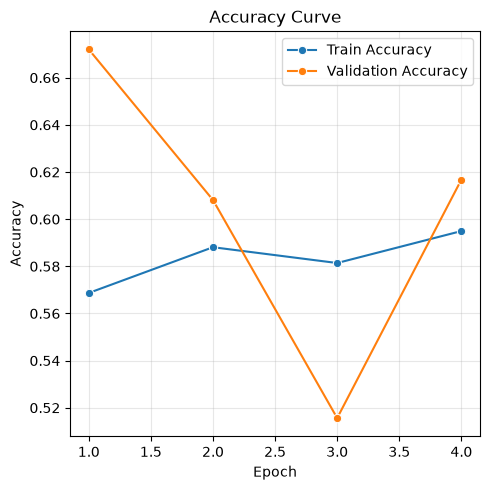

In [172]:
plt.figure(figsize=(5, 5))

sns.lineplot( data=hyper_df, x=hyper_df.index + 1, y='accuracy',marker='o', label='Train Accuracy')
sns.lineplot( data=hyper_df, x=hyper_df.index + 1, y='val_accuracy',marker='o', label='Validation Accuracy')

plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

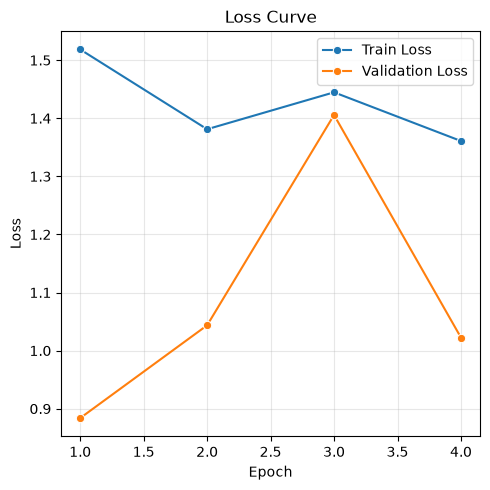

In [173]:
plt.figure(figsize=(5, 5))
sns.lineplot(data=hyper_df, x=hyper_df.index + 1, y='loss',marker='o', label='Train Loss')
sns.lineplot(data=hyper_df, x=hyper_df.index + 1, y='val_loss',marker='o', label='Validation Loss')

plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [174]:
effecientnet_model = keras.models.load_model(r'../models/hyper_effecient.keras')

predict_prob = resenet_model.predict(test_dataset2)

y_pred = np.argmax(predict_prob, axis=1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step


In [175]:
from sklearn.metrics import auc, roc_curve

In [176]:
y_true_bin = label_binarize(y_true,classes=np.arange(7))

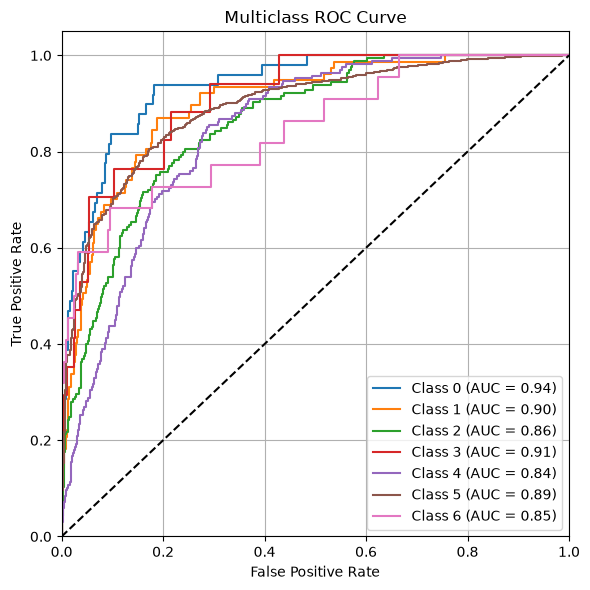

In [177]:
n_classes = y_true_bin.shape[1]

plt.figure(figsize=(6, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], predict_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()

plt.show()

In [178]:
from sklearn.metrics import precision_recall_curve, average_precision_score

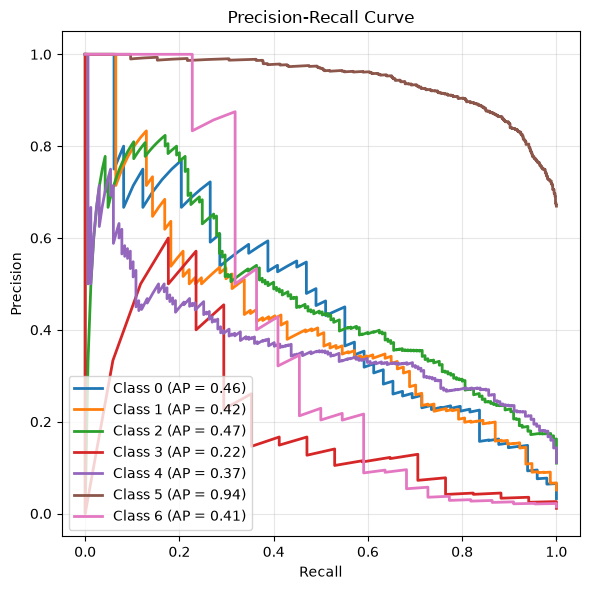

In [179]:
n_classes = y_true_bin.shape[1]

plt.figure(figsize=(6, 6))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i],predict_prob[:, i])
    ap = average_precision_score(y_true_bin[:, i], predict_prob[:, i])
    plt.plot(recall, precision,lw=2,label=f'Class {i} (AP = {ap:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [180]:
cm = confusion_matrix(y_true, y_pred, normalize='true')

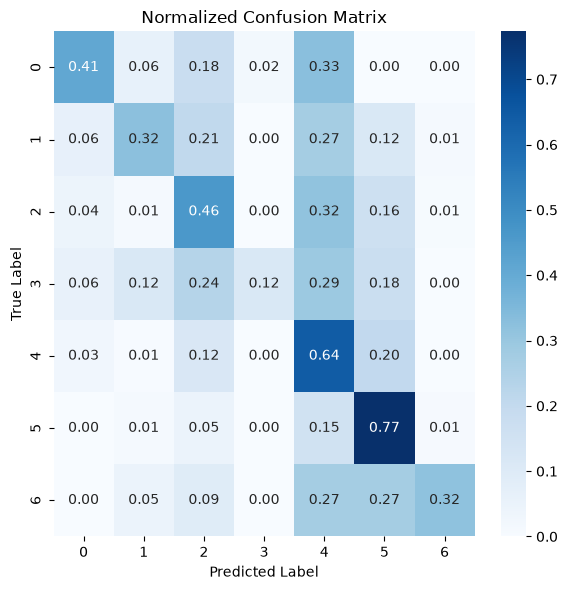

In [181]:
plt.figure(figsize=(6, 6))

sns.heatmap(cm,annot=True,fmt=".2f",cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()

plt.show()

In [182]:
mat_app

<function __main__.mat_app(model, accuracy, precision, recall, f1, roc)>

In [183]:
performance_dict = {
    'MODEL': evalution_dict['model'],
    'ACCURACY': evalution_dict['accuracy'],
    'LOSS': [0.74, 1.32, 1.92, 1.17, 0.92, 0.80, 0.87, 1.01]
}

df = pd.DataFrame(performance_dict)

df.to_csv(r'../data/selected_col/performance.csv')

In [6]:
df = pd.read_csv(r'../data/selected_col/performance.csv',)

df

,Unnamed: 0,MODEL,ACCURACY,LOSS
0,0,BASE LINE,0.607452,0.74
1,1,DEEP CNN,0.502994,1.32
2,2,BATCH CNN,0.669328,1.92
3,3,DROP CNN,0.637392,1.17
4,4,MOBILE NET,0.666001,0.92
5,5,EFFECIENT NET,0.713906,0.80
6,6,RESNET,0.675316,0.87
7,7,DENSE NET,0.612109,1.01
